# **Linear Regression Using Neural Network**

In [ ]:
# install dependencies untuk menjalankan notebook ini
# !pip install -r requirements.txt

In [3]:
# Import Library
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# **Import Dataset**

In [4]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

# Membaca dataset sesuai nama file
df = pd.read_csv('weatherHistory.csv')

# Menampilkan 5 baris pertama
df.head()

Saving requirements.txt.txt to requirements.txt (1).txt
Saving weatherHistory.csv to weatherHistory (1).csv


,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


In [ ]:
# Check Dataset -> kolomnya ada apa aja
print(df.columns)

# daily summary, formatted date, itu ga perlu, jadi di drop aja

Index(['Formatted Date', 'Summary', 'Precip Type', 'Temperature (C)',
       'Apparent Temperature (C)', 'Humidity', 'Wind Speed (km/h)',
       'Wind Bearing (degrees)', 'Visibility (km)', 'Loud Cover',
       'Pressure (millibars)', 'Daily Summary'],
      dtype='object')


In [ ]:
# Feature Selection -> memilih atribut yang hanya kt perlukan dan buang yang tidak diperlukan

# prediksi: Humidity
dataset = dataset.drop([
    'Formatted Date', 
    'Summary', 
    'Precip Type', 
    'Loud Cover', 
    'Daily Summary'
], axis=1
)

# axis -> ara operasi yang akan dilakukan pada dataframe
# 0 -> row
# 1 -> column

In [9]:
# Check Dataset 2 (apakah columnya udah dihapus atau belum)
print(df.columns)

Index(['Formatted Date', 'Summary', 'Precip Type', 'Temperature (C)',
       'Apparent Temperature (C)', 'Humidity', 'Wind Speed (km/h)',
       'Wind Bearing (degrees)', 'Visibility (km)', 'Loud Cover',
       'Pressure (millibars)', 'Daily Summary'],
      dtype='object')


In [10]:
# Menentukan feature yang akan menjadi target dan non target

# Non Target Features -> semua feature yang digunakan untuk menebak Humidity
non_target_features = df.drop(['Humidity'], axis=1)

# Target Feature -> feature yang ingin ditebak
target_features = df['Humidity']

In [11]:
# Split Data
# Ratio -> 80 (training) : 10 (testing) : 10 (validation)

x_train, x_temp, y_train, y_temp = train_test_split(non_target_features, target_features, test_size=0.2, random_state=19)

# Pembagian Testing and Validation
x_test, x_val, y_test, y_val = train_test_split(x_temp, y_temp, test_size=0.5, random_state=19)

In [16]:
# install dependencies untuk menjalankan notebook ini
!pip install -r requirements.txt.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.0/38.0 MB 13.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 28.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


In [21]:
# Standarisasi Data

# 1. Buat Scaler
scaler = StandardScaler()

# 2. Standarisasi Data
# Training -> fit transform
x_train = scaler.fit_transform(x_train)

# Testing and Validating -> transform
x_test = scaler.transform(x_test)
x_val = scaler.transform(x_val)

In [22]:
# Build Model

model = Sequential([
    Dense(32, activation="relu", input_dim= x_train.shape[1]),
    Dense(16, activation="relu"),
    Dense(8, activation="relu"),
    Dense(1, activation="linear")
])

# Compile Model
model.compile(optimizer="adam", loss="mae", metrics=["mean_squared_error"])
# Optimizer -> algoritma yang membantu model memperbaiki kesalahan / bobotnya
# Loss Function -> seberapa jauh prediksi model dari target sebenarnya
# Metrics -> Memantau / mengukur performa dari model selama proses training + evaluasi

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [23]:
# Model Training

history = model.fit(x_train, y_train, epochs=100, batch_size=256, validation_data=(x_val, y_val))

Epoch 1/100
302/302 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.1671 - mean_squared_error: 0.0593 - val_loss: 0.0991 - val_mean_squared_error: 0.0175
Epoch 2/100
302/302 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0950 - mean_squared_error: 0.0163 - val_loss: 0.0935 - val_mean_squared_error: 0.0161
Epoch 3/100
302/302 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0909 - mean_squared_error: 0.0151 - val_loss: 0.0911 - val_mean_squared_error: 0.0151
Epoch 4/100
302/302 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0887 - mean_squared_error: 0.0144 - val_loss: 0.0884 - val_mean_squared_error: 0.0147
Epoch 5/100
302/302 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0870 - mean_squared_error: 0.0140 - val_loss: 0.0874 - val_mean_squared_error: 0.0144
Epoch 6/100
302/302 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0862 - mean_squared_error: 0.0138 - val_loss: 0.0881 - val_mean_squared_error: 0.0141
Epoch 7/100
302/302 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0854 - mean_squared_error: 0.0136 - val_los

In [24]:
# Model Evaluation

loss, mse = model.evaluate(x_test, y_test)
print("Loss:", loss)
print("MSE:", mse)


302/302 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0783 - mean_squared_error: 0.0118
Loss: 0.07829608023166656
MSE: 0.01179521158337593


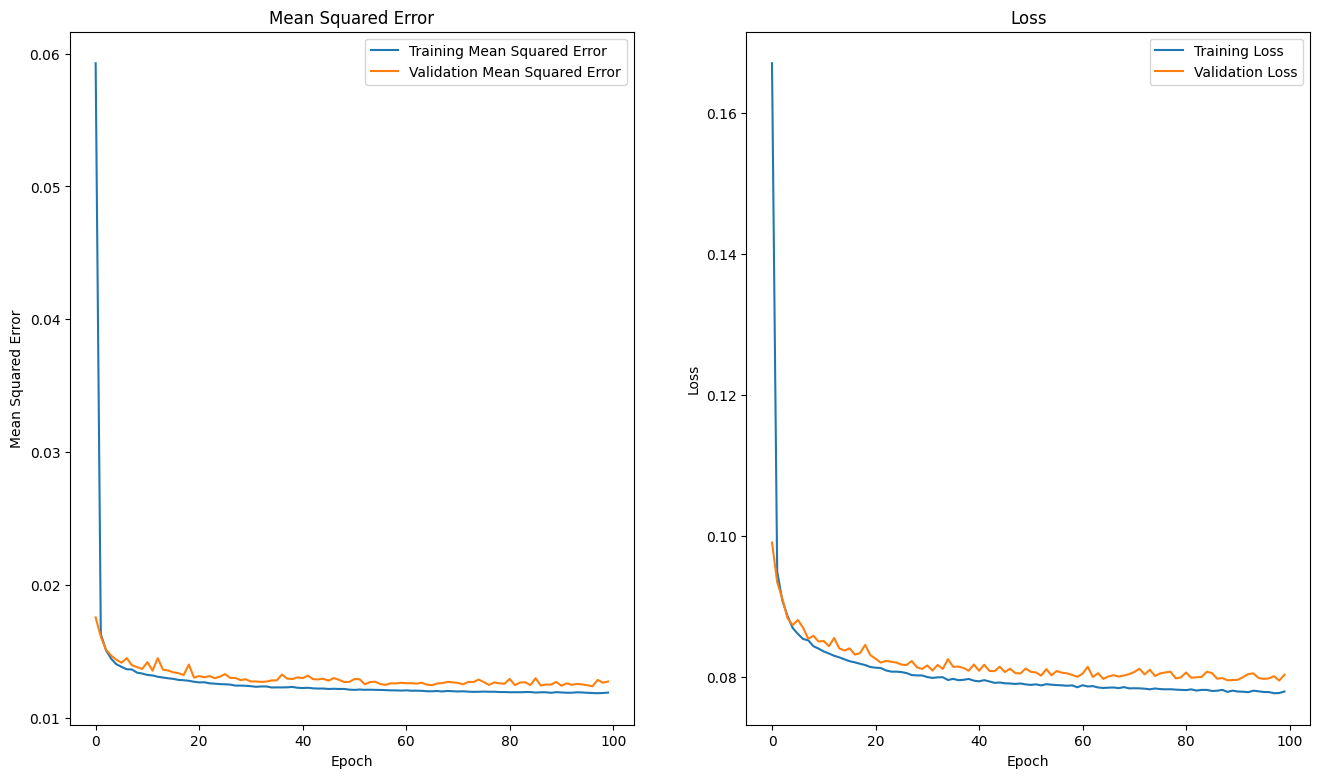

In [25]:
# Evaluasi Menggunakan Plotting

plt.figure(figsize=(16, 9))
plt.subplot(1, 2, 1)

# sebelah kiri -> mse
plt.plot(history.history['mean_squared_error'], label = "Training Mean Squared Error")
plt.plot(history.history['val_mean_squared_error'], label = "Validation Mean Squared Error")
plt.title("Mean Squared Error")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.legend()

# sebelah kanan -> loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label = "Training Loss")
plt.plot(history.history['val_loss'], label = "Validation Loss")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Save hasilnya
# plt.savefig("Model_Evaluation.png")

# Show hasilnya
plt.show()

In [26]:
# Prediction Using Model

# 1. Buat list kosong -> prediction values, actual values
prediction_values = []
actual_values = []

# 2. Predict
predictions = model.predict(x_test[:5])
actual = y_test[:5].values

# 3. Masukkan hasil prediksi ke dalam list
for value in predictions:
  prediction_values.append(value[0])

# 4. Masukkan hasil aktual ke dalam list
for value in y_test:
  actual_values.append(value)

# 5. Print hasilnya
print("Actual                          Predicted")
print("==========================================")
for (predicted, actual) in zip(prediction_values, actual_values):
  print(f"{actual}                        {predicted}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
Actual                          Predicted
0.8                        0.8128197193145752
1.0                        0.9929074048995972
0.65                        0.7692301273345947
0.39                        0.40736252069473267
0.41                        0.40502744913101196
